In [12]:
import os
import numpy as np
import pandas as pd
import torch 
from torch import nn
from torch.utils.data import DataLoader

import pytorch_lightning as pl
from pytorch_lightning import callbacks 
from pytorch_lightning import loggers as pl_loggers

import models
from reader import Pdyn_ExtractDataset
from matplotlib import pyplot as pl

In [13]:
%load_ext autoreload
%autoreload 2

In [28]:
import pl as pl_fun

# read data

In [14]:
pt_path = 'dataExample.pt'

train_DS = Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=300, n_repeat=10)
val_DS= Pdyn_ExtractDataset(Data_pt=pt_path, n_grid=300, collocation_points=600, n_repeat=1)

train_iter = iter(DataLoader(train_DS, batch_size=1, num_workers=4))

# val_DL = DataLoader(val_DS, batch_size=1, num_workers=4)

# load Cspline KLD sym model

In [15]:
main_dir = "/ssd/users/wergillius/Project/PINN_dynamics"

# v3
ckpt3 = "../logs/Cspline_symKLD/lightning_logs/version_3/checkpoints/epoch=154-total_loss=12.95298767.ckpt"

# v5
ckpt5 = "../logs/Cspline_symKLD/lightning_logs/version_5/checkpoints/epoch=42-total_loss=13.86048889.ckpt"


In [16]:
modelv3 = models.Cspline_PINN.load_from_checkpoint(ckpt3)
modelv5 = models.Cspline_PINN.load_from_checkpoint(ckpt5)

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


# make prediction

In [17]:
# get data
data_batch = next(train_iter)

# version 3

In [37]:
s_col, t_col, s_all, t_b, u_b, Mean, Var = modelv3.get_data(data_batch, False)

In [44]:
u_b = u_b.detach().cpu().squeeze()

In [45]:

Mean_b = 0.5*(u_b[:,1:]+u_b[:,:-1]).sum(axis=1)

In [47]:
Mean_b, Mean

(tensor([ 9.6028, 10.4388, 11.0377, 11.5617, 12.0297, 12.4874]),
 tensor([[ 9.6028],
         [10.4388],
         [11.0377],
         [11.5617],
         [12.0297],
         [12.4874]]))

In [48]:
n_time = 10
i = 0


for i in range(300-n_time):
    s_range = slice(i, i+n_time)
    u_pred_mini = u_pred_b[:, s_range]
    u_mini = u_b[:, :10]

    
    Mean_b = 0.5*(u_mini[:10,1:]+u_mini[:1,:-1]).sum(axis=1)
    N_b = 0.5*(u_pred_mini[:10,1:]+u_pred_mini[:1,:-1]).sum(axis=1)

    print(i, Mean_b - N_b)

0 tensor([0.6644, 0.0131, 0.1556, 0.1907, 0.1931, 0.1919])
1 tensor([0.6692, 0.0155, 0.1573, 0.1922, 0.1945, 0.1933])
2 tensor([0.6740, 0.0179, 0.1589, 0.1937, 0.1960, 0.1948])
3 tensor([0.6787, 0.0203, 0.1606, 0.1952, 0.1975, 0.1963])
4 tensor([0.6835, 0.0227, 0.1623, 0.1967, 0.1990, 0.1979])
5 tensor([0.6883, 0.0252, 0.1639, 0.1983, 0.2006, 0.1994])
6 tensor([0.6932, 0.0276, 0.1656, 0.1998, 0.2021, 0.2009])
7 tensor([0.6980, 0.0301, 0.1673, 0.2014, 0.2036, 0.2024])
8 tensor([0.7028, 0.0326, 0.1690, 0.2030, 0.2052, 0.2040])
9 tensor([0.7077, 0.0351, 0.1707, 0.2045, 0.2067, 0.2055])
10 tensor([0.7126, 0.0376, 0.1724, 0.2061, 0.2083, 0.2071])
11 tensor([0.7175, 0.0401, 0.1742, 0.2077, 0.2098, 0.2086])
12 tensor([0.7224, 0.0426, 0.1759, 0.2093, 0.2114, 0.2102])
13 tensor([0.7273, 0.0452, 0.1777, 0.2109, 0.2130, 0.2118])
14 tensor([0.7322, 0.0477, 0.1794, 0.2125, 0.2146, 0.2134])
15 tensor([0.7371, 0.0503, 0.1812, 0.2141, 0.2162, 0.2150])
16 tensor([0.7421, 0.0529, 0.1830, 0.2158, 0.2178,

tensor([1.3918, 0.4516, 0.4492, 0.4521, 0.4455, 0.4414])
145 tensor([1.3963, 0.4550, 0.4514, 0.4539, 0.4472, 0.4430])
146 tensor([1.4009, 0.4584, 0.4535, 0.4556, 0.4488, 0.4446])
147 tensor([1.4054, 0.4618, 0.4556, 0.4574, 0.4505, 0.4462])
148 tensor([1.4099, 0.4652, 0.4577, 0.4591, 0.4521, 0.4478])
149 tensor([1.4144, 0.4686, 0.4598, 0.4609, 0.4538, 0.4493])
150 tensor([1.4189, 0.4720, 0.4619, 0.4626, 0.4554, 0.4509])
151 tensor([1.4234, 0.4754, 0.4640, 0.4644, 0.4570, 0.4525])
152 tensor([1.4279, 0.4788, 0.4661, 0.4661, 0.4586, 0.4540])
153 tensor([1.4323, 0.4822, 0.4682, 0.4678, 0.4602, 0.4556])
154 tensor([1.4367, 0.4856, 0.4703, 0.4695, 0.4618, 0.4571])
155 tensor([1.4411, 0.4890, 0.4724, 0.4712, 0.4634, 0.4587])
156 tensor([1.4455, 0.4924, 0.4745, 0.4729, 0.4650, 0.4602])
157 tensor([1.4499, 0.4958, 0.4766, 0.4746, 0.4666, 0.4617])
158 tensor([1.4542, 0.4992, 0.4786, 0.4763, 0.4681, 0.4632])
159 tensor([1.4585, 0.5026, 0.4807, 0.4780, 0.4697, 0.4648])
160 tensor([1.4628, 0.5060, 

In [32]:
u_pred_b.shape

(6, 300)

In [31]:
u_pred_b, _ = pl_fun.predict_and_vis(modelv3, data_batch, train_DS, False, False)

[ 9.559527 10.594599 11.336258 11.762161 12.414702 12.799729]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


# version 4

In [23]:
ckptv4 = "../logs/Cspline_symKLD/lightning_logs/version_4/checkpoints/epoch=0-total_loss=118.95298767.ckpt"
modelv4 = models.Cspline_symKLD.load_from_checkpoint(ckptv4)

/ssd/users/wergillius/.conda/envs/pytorch/lib/python3.8/site-packages/pytorch_lightning/utilities/parsing.py:268: UserWarning: Attribute 'u' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['u'])`.
  rank_zero_warn(


[-2.5884886 10.496391  15.647579  18.537672  21.300413  23.856535 ]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


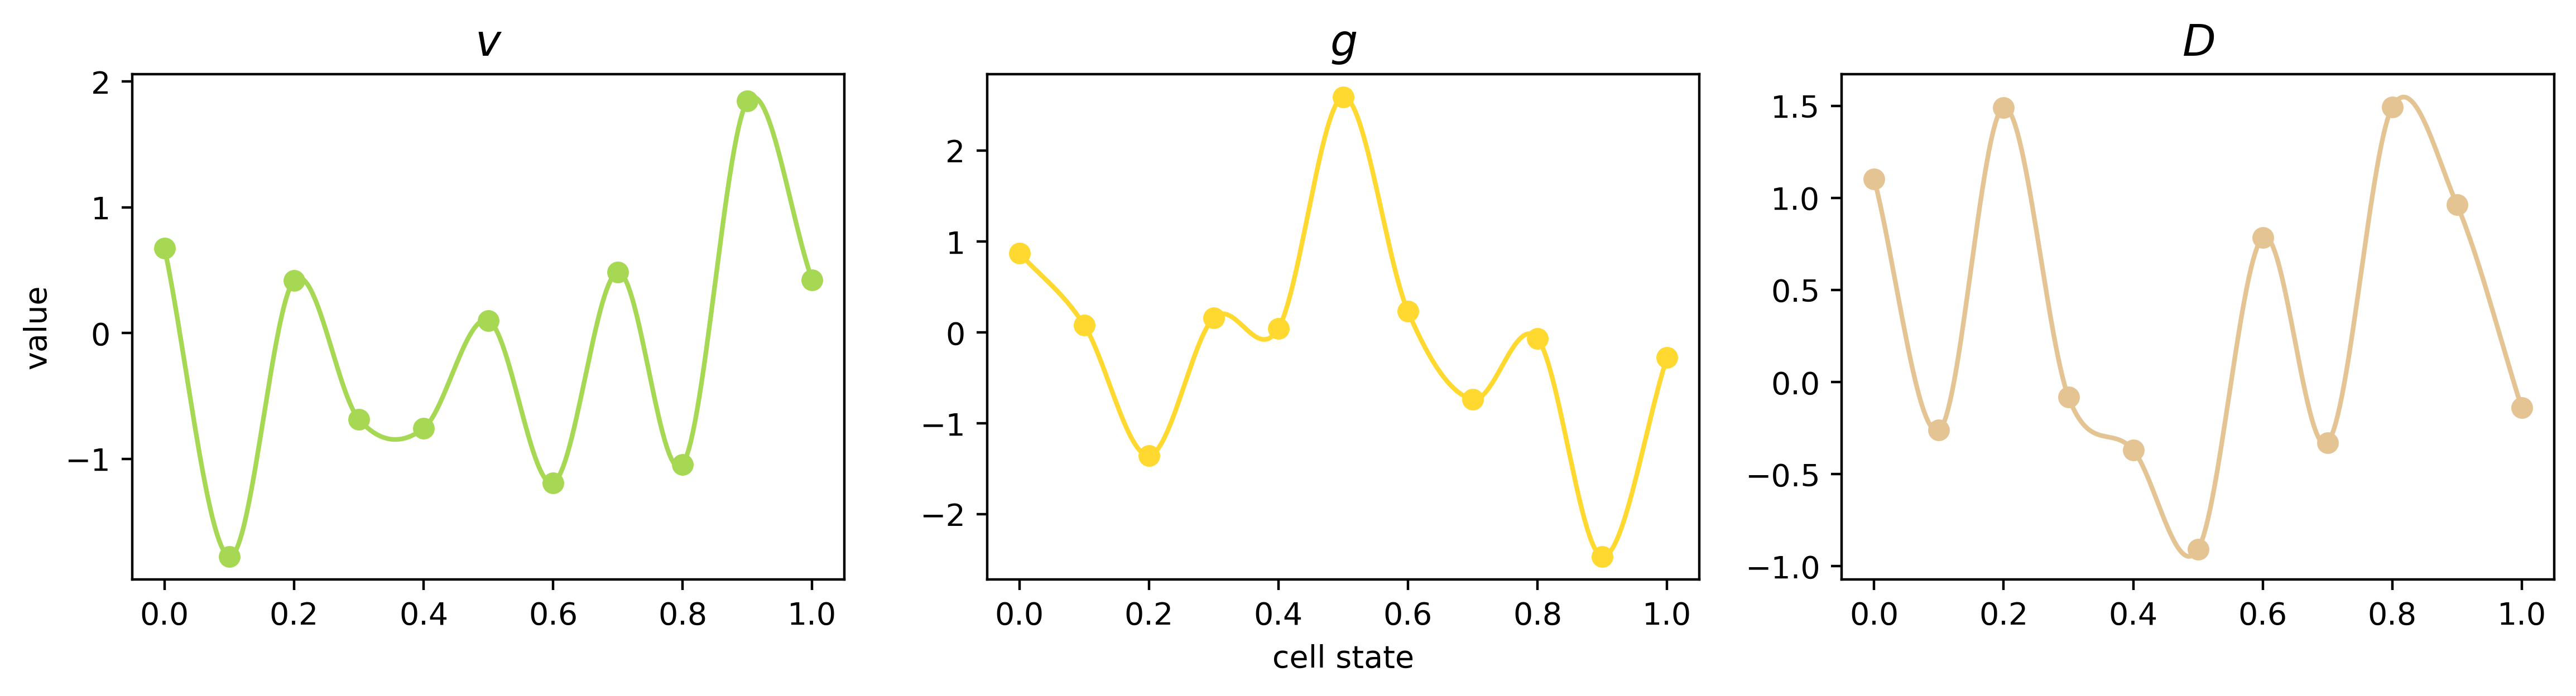

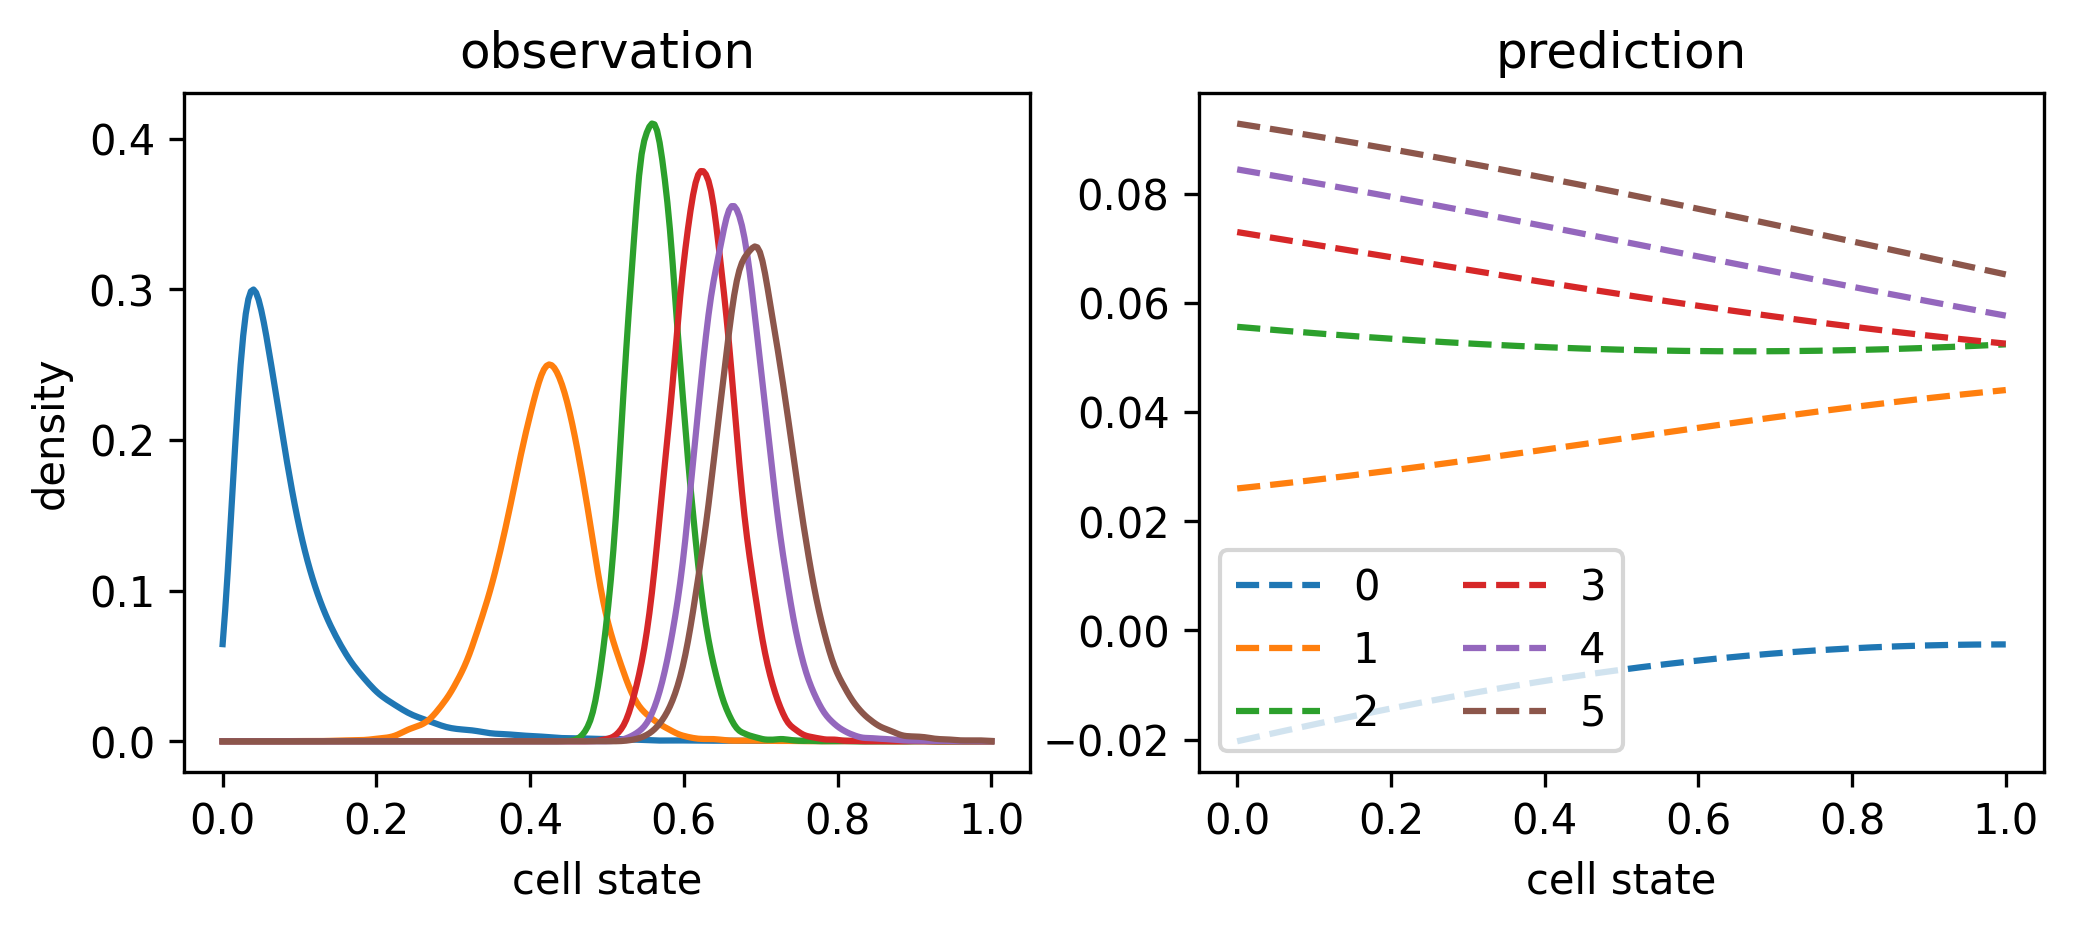

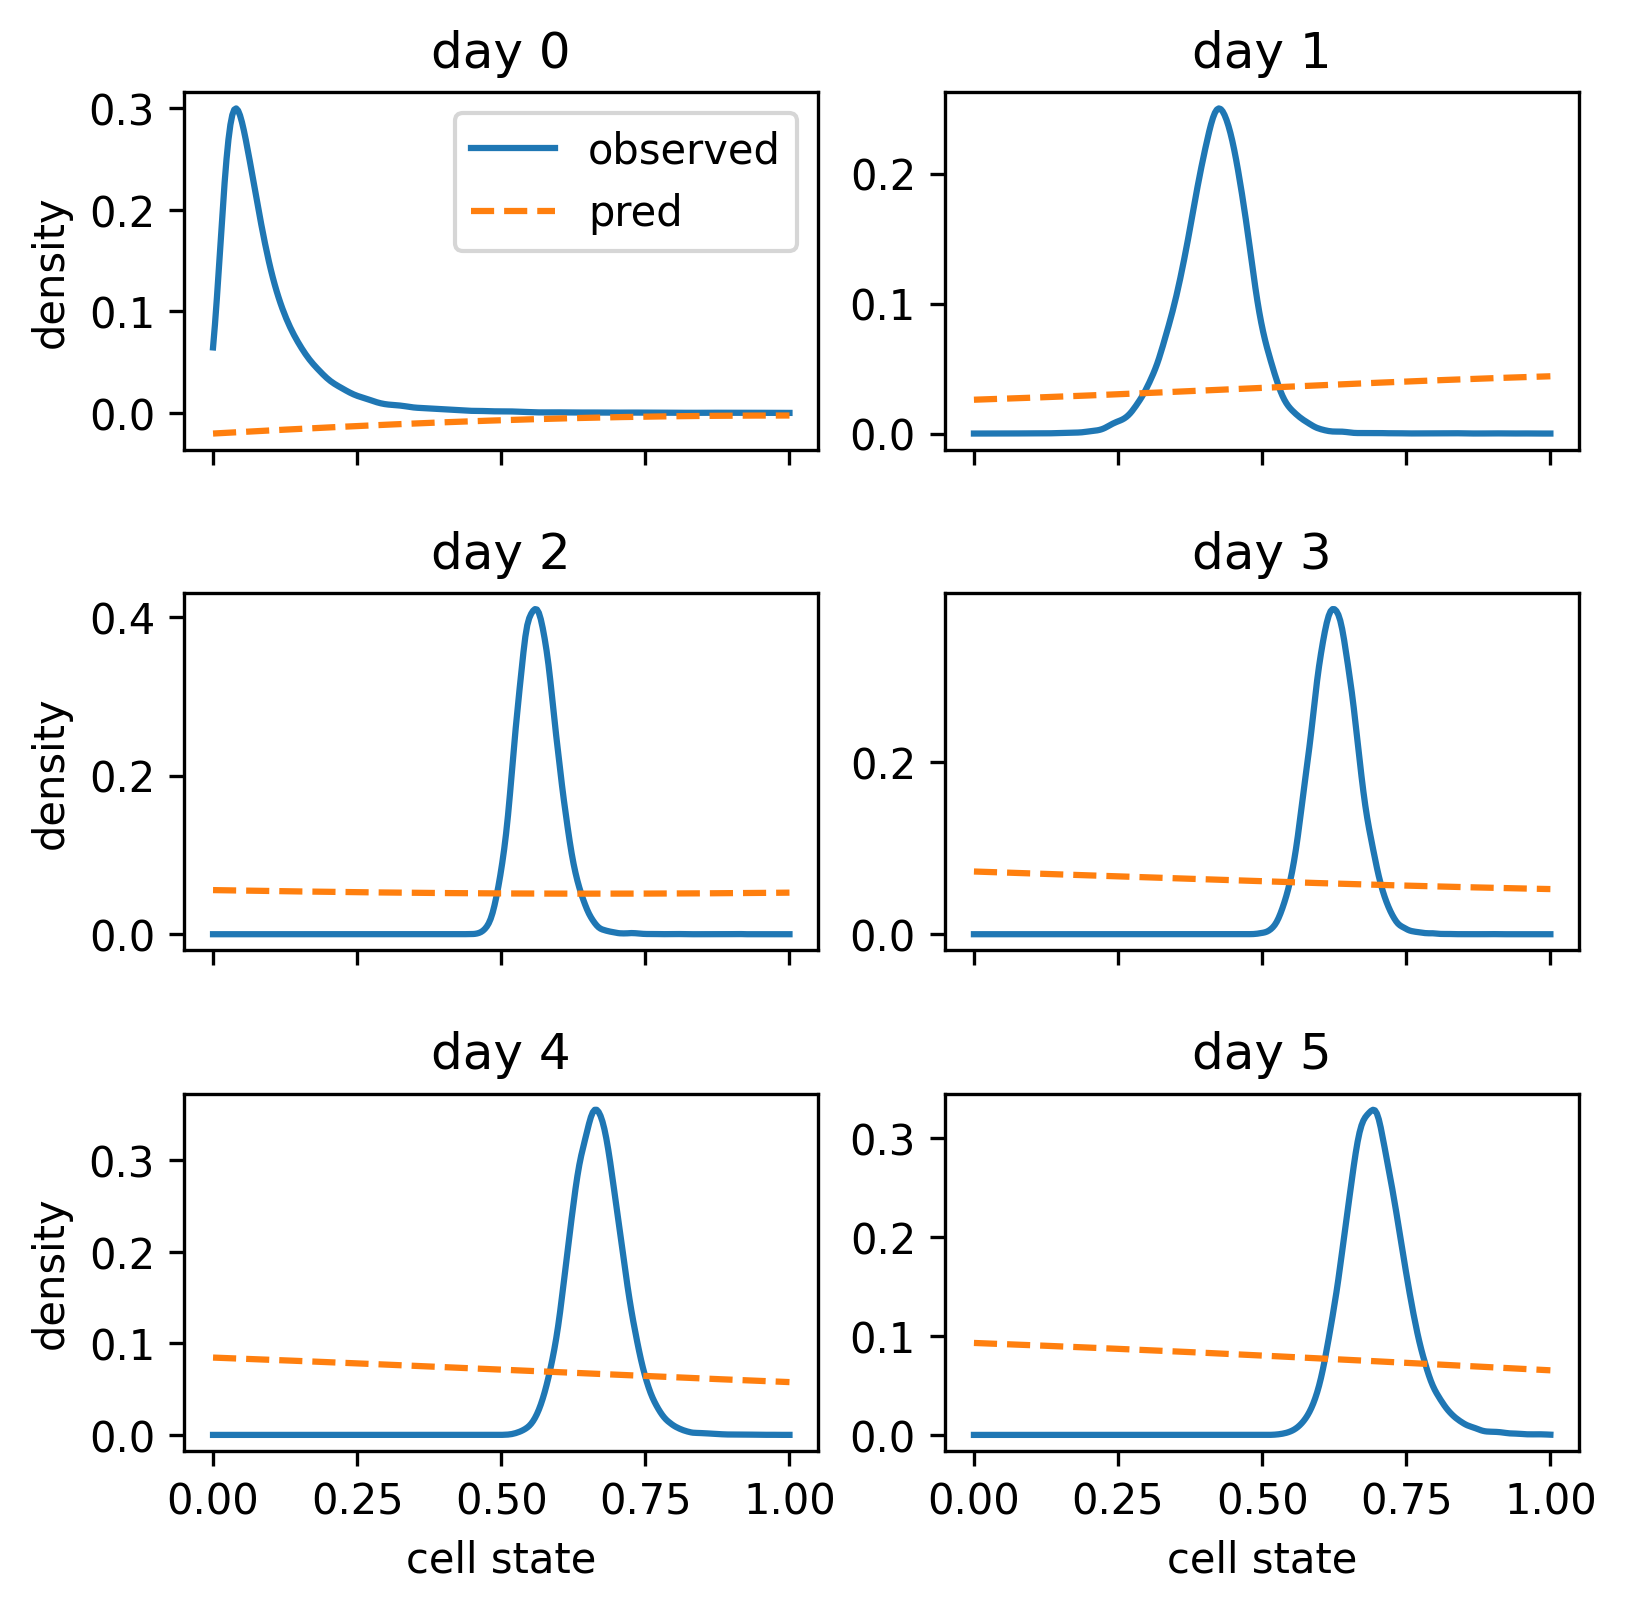

In [27]:
u_pred_b = pl_fun.predict_and_vis(modelv4, data_batch, train_DS)

# version 5

[ 9.373944 10.309944 10.724037 11.454128 12.081175 12.451027]
[ 9.602811  10.438831  11.037735  11.5617075 12.029749  12.487436 ]


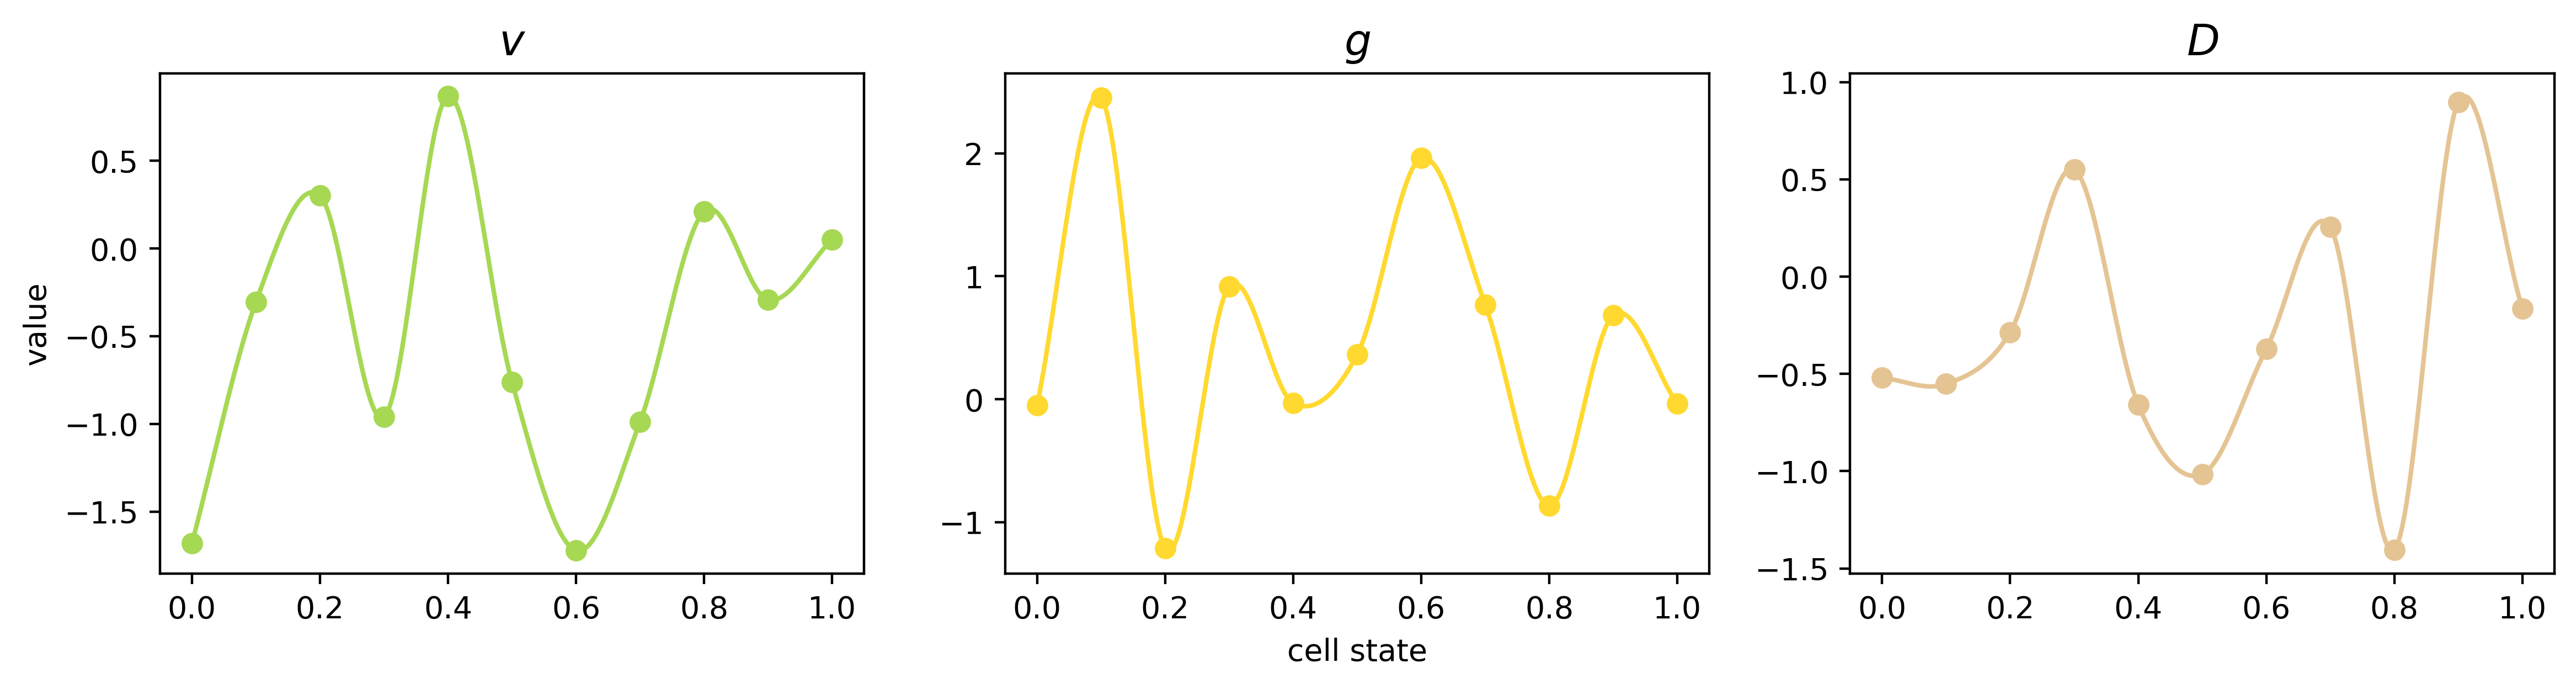

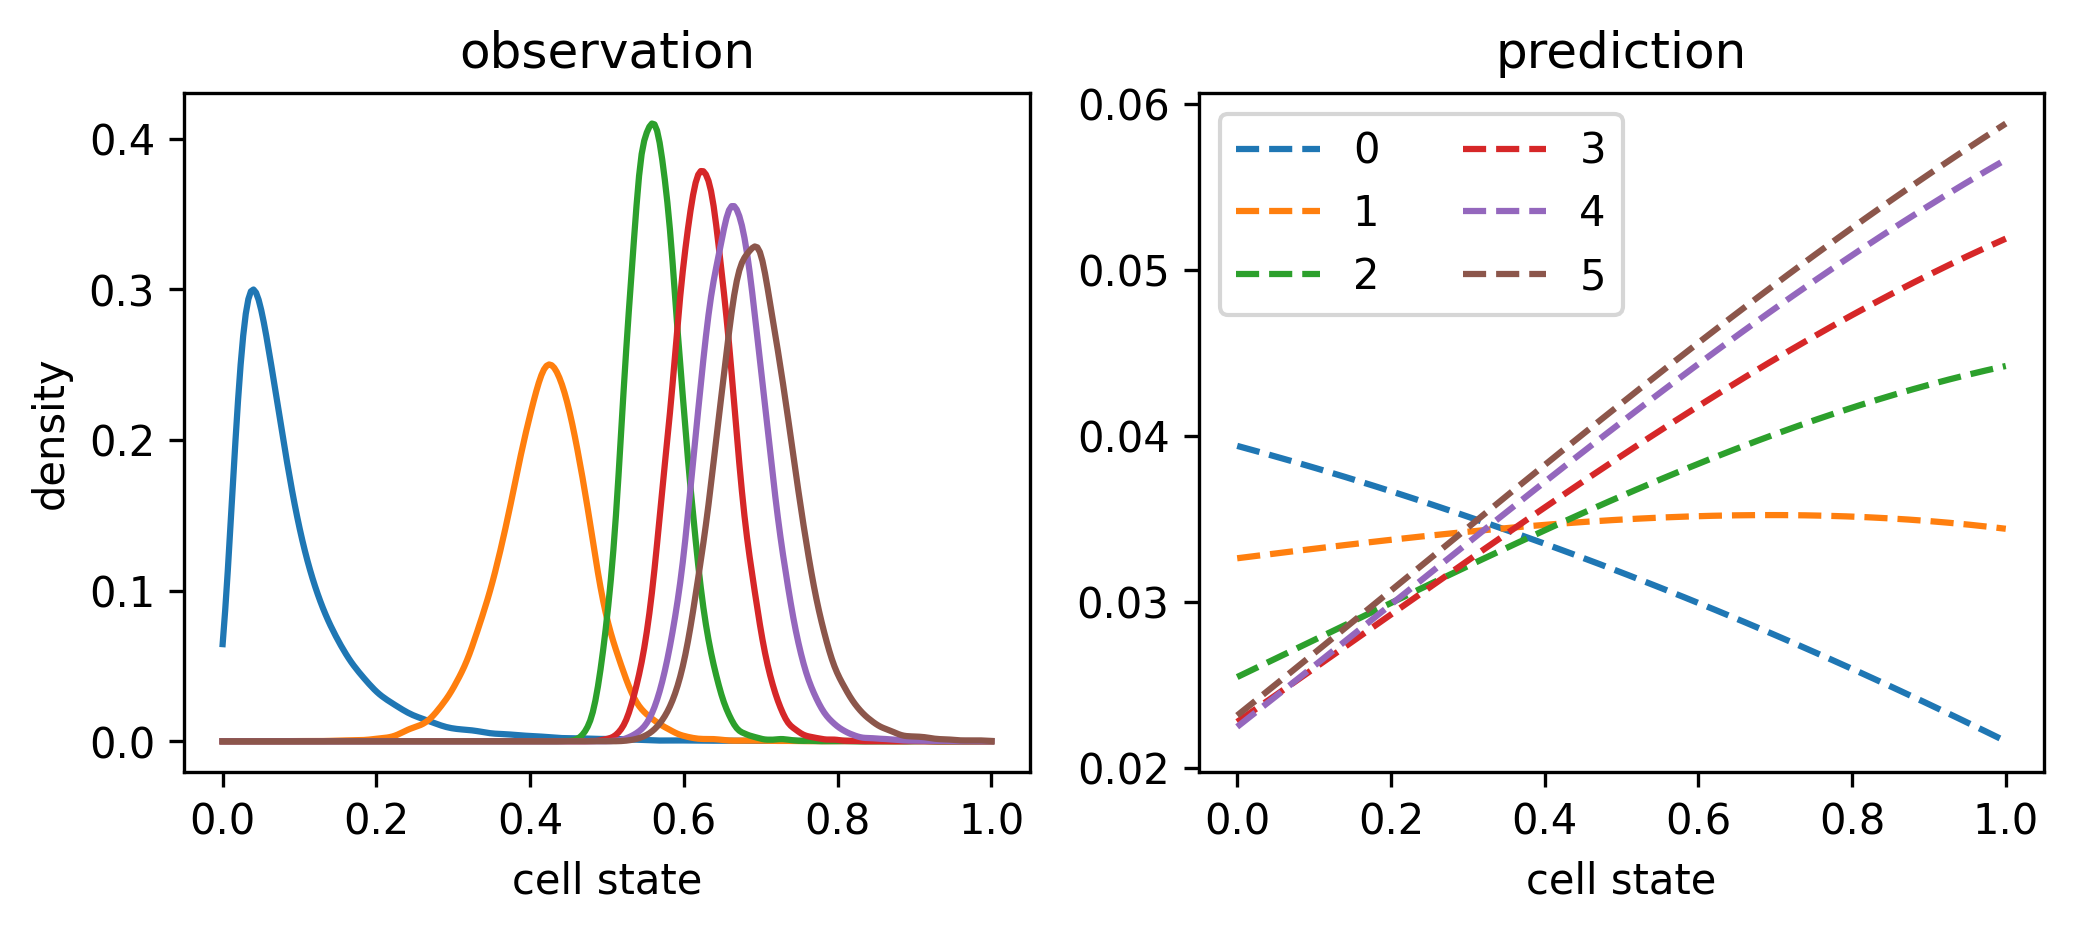

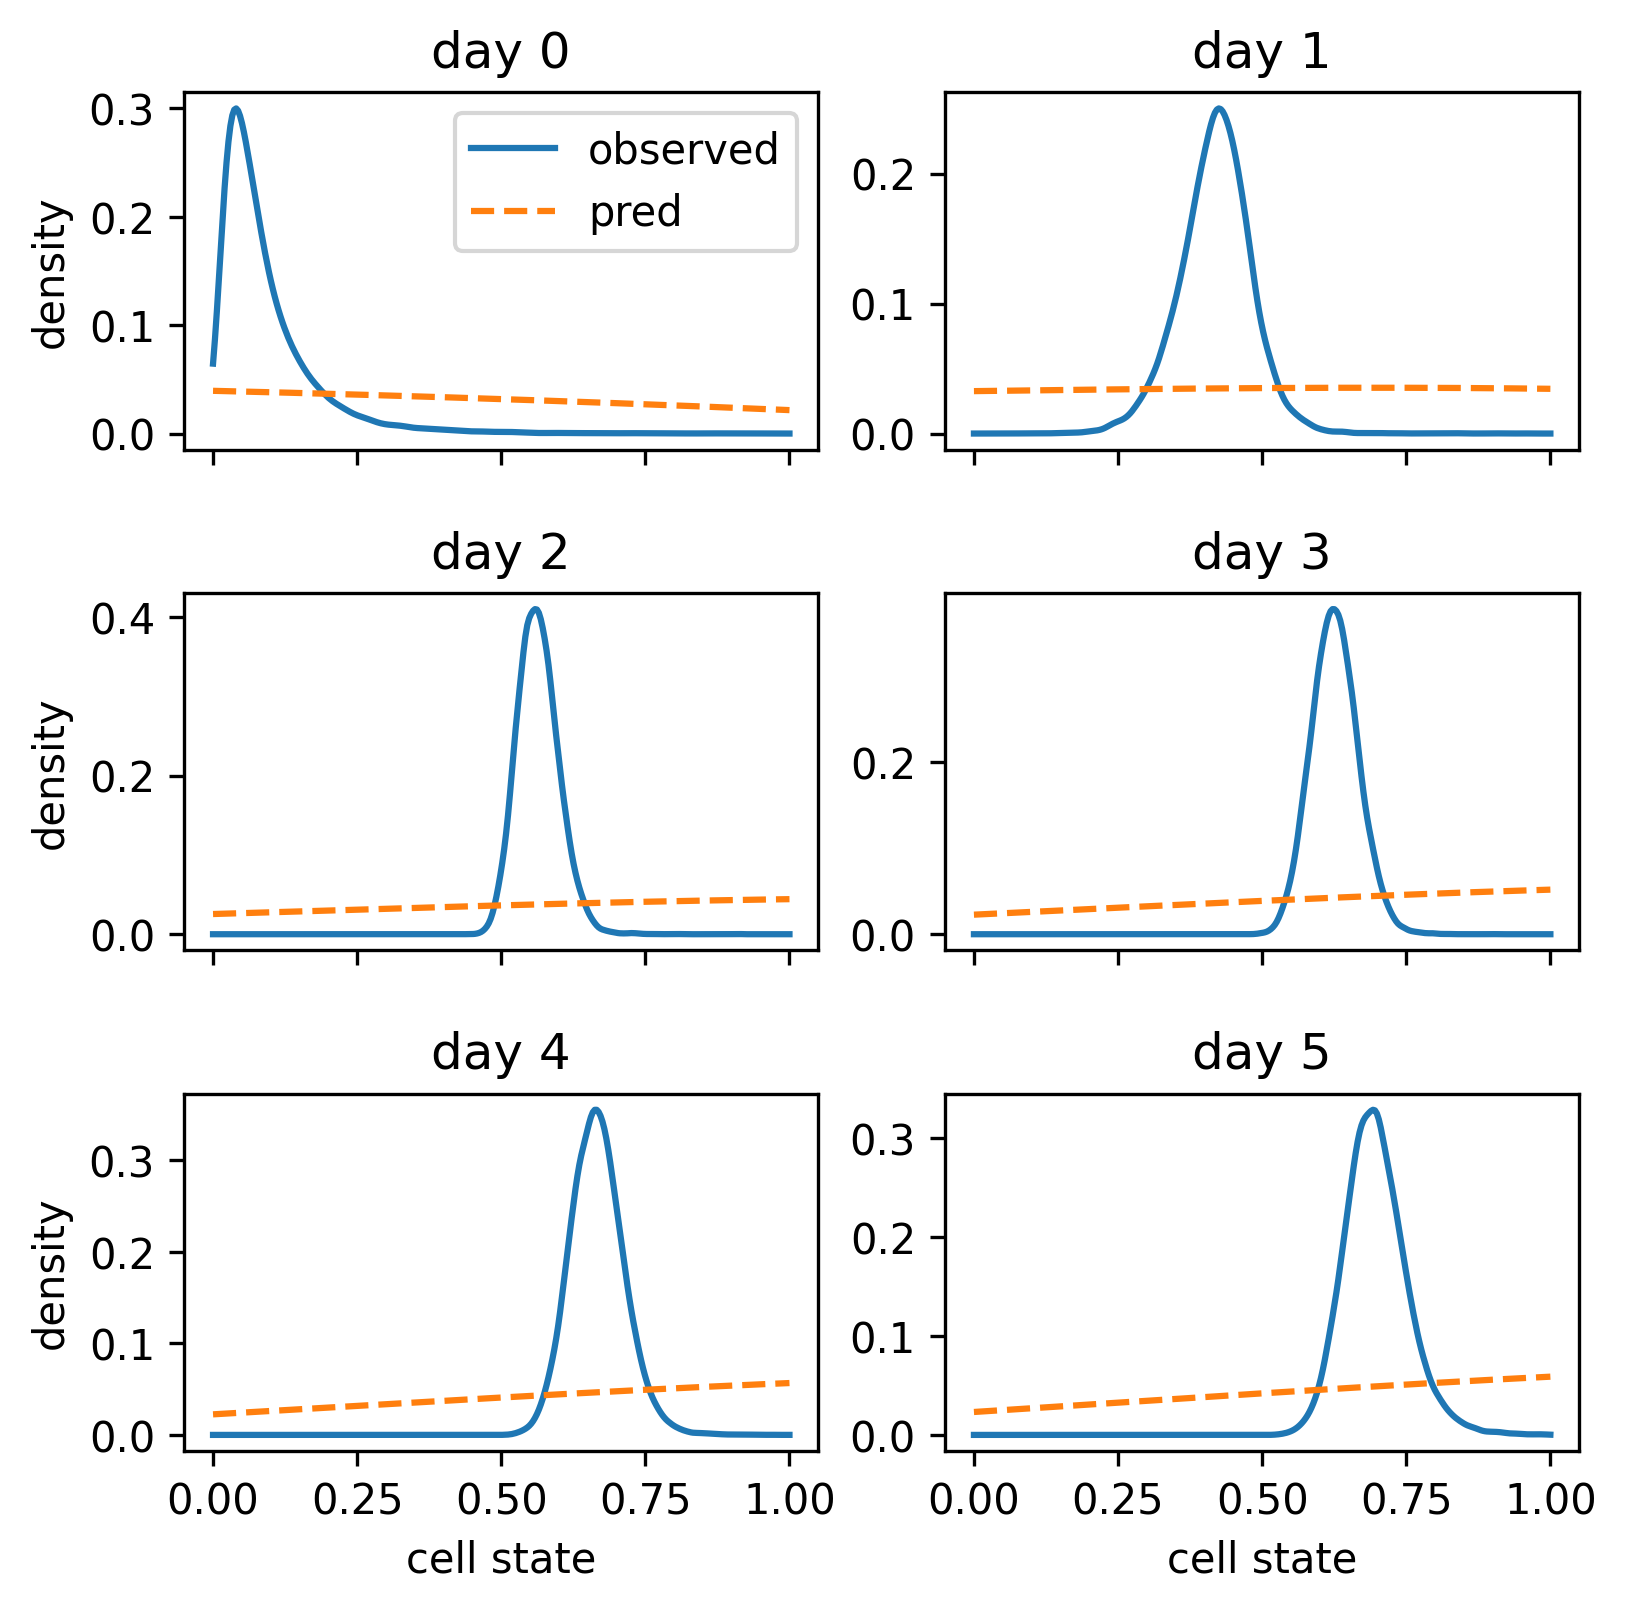

In [28]:
u_pred_b = pl_fun.predict_and_vis(modelv5, data_batch, train_DS)